# The effect of climate change on labor supply in India

This notebook aggregates the effect of climate change on labor
supply, in minutes worked per worker per day, from impact regions to
Indian states, and values it in 2005 PPP USD. India has 2,300 impact
regions and 35 states in GADM 2.0.

The sample is one Monte Carlo batch, all 33 climate models, rcp85,
SSP3, low income scenario, years 2090 to 2099, from the
uninteracted_main_model tree, the 2020 labor release model. The
numbers are a demonstration, not results.

In [1]:
import sys
from pathlib import Path

import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

sys.path.insert(0, ".")
import compute
import cil_regionalization as cilreg

states = gpd.read_parquet(compute.DATA / "ind_adm1_plot.parquet")
print(len(states), "states;", len(compute.draws()), "draws")

35 states; 33 draws


rebased represents the impact relative to each scenario’s own 2001–2010 average, measured in minutes worked per worker per day. To isolate the effect of climate change, we take the difference between each scenario and its corresponding -histclim case. Negative values represent losses in labor time.

rebased combines the high- and low-risk groups using the projected share of employment in high-risk activities. Valuation is applied to these combined minutes using a single income-based rate.

In [2]:
draw = compute.load_draw("batch0", "CCSM4")
d99 = draw[draw["year"] == 2099]
pop = d99.set_index("hierid")["population"]

scen = compute.read_rebased("batch0", "CCSM4", compute.STEM + ".nc4", "v")
hist = compute.read_rebased("batch0", "CCSM4", compute.STEM + "-histclim.nc4", "v")

def national(df):
    s = df[df["year"] == 2099].set_index("hierid")["v"].reindex(pop.index)
    return float((s * pop).sum() / pop.sum())

for label, value in (
    ("full adaptation, rebased alone", national(scen)),
    ("histclim, rebased alone", national(hist)),
    ("effect of climate change",
     float((d99["minutes"] * d99["population"]).sum() / d99["population"].sum())),
):
    print(f"{label:32s} {value:+7.2f} minutes per worker per day, 2099")

full adaptation, rebased alone     -4.22 minutes per worker per day, 2099
histclim, rebased alone            -0.03 minutes per worker per day, 2099
effect of climate change           -4.19 minutes per worker per day, 2099


## Minutes per worker per day, by state

State-level values are calculated as population-weighted averages of the regional impacts using the per_source weights. Total population is used for the weighting, since the labor share is already accounted for in the valuation._

In [3]:
r = compute.ratio_rate(draw)
r99 = r[r["year"] == 2099].merge(states[["ISO", "ID_1", "NAME_1"]], on=["ISO", "ID_1"])
print("one draw (CCSM4), 2099, largest losses:")
print(r99.nsmallest(5, "minutes")[["NAME_1", "minutes"]].round(2).to_string(index=False))

one draw (CCSM4), 2099, largest losses:
        NAME_1  minutes
       Gujarat    -5.28
Andhra Pradesh    -5.25
        Punjab    -5.06
    Puducherry    -4.87
     Rajasthan    -4.81


## Valued in dollars

The dollar value is calculated from the physical impact using a region- and year-specific factor: population x income x 0.00487. This converts the impact in minutes into a share of annual labor income and accounts for the disutility of lost labor time.

The example below reconstructs the valued results for CCSM4 using this factor and compares them with the corresponding output.

In [4]:
wage = compute.read_rebased("batch0", "CCSM4", compute.STEM + "-wage-levels.nc4", "wage")
hist = compute.read_rebased("batch0", "CCSM4", compute.STEM + "-histclim-wage-levels.nc4", "hist")
real = wage.merge(hist, on=["hierid", "year"])
real["value"] = real["wage"].astype("float64") - real["hist"].astype("float64")
both = real[["hierid", "year", "value"]].merge(
    draw[["hierid", "year", "value"]], on=["hierid", "year"],
    suffixes=("_files", "_factor"))
err = (both["value_factor"] - both["value_files"]).abs().max() / both["value_files"].abs().max()
print(f"rebuilt against the files: largest difference {err:.1e} of the largest value")

v = compute.valued_total(draw)
v99 = v[v["year"] == 2099]
input_total = draw[draw["year"] == 2099]["value"].sum()
print(f"2099 mass balance: impact regions {input_total:.6e}, "
      f"states {v99['value'].sum():.6e}")

rebuilt against the files: largest difference 5.7e-08 of the largest value
2099 mass balance: impact regions -8.816661e+11, states -8.816661e+11


##  Across the draws
Results are averaged over 2090–2099 for each draw and then combined using the SMME climate-model weights (doi:10.5281/zenodo.22003542).

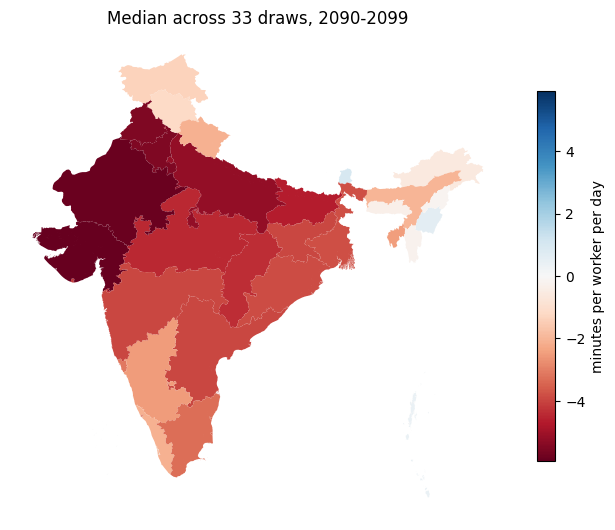

In [5]:
phys_frames, val_frames = [], []
for batch, gcm in compute.draws():
    d = compute.load_draw(batch, gcm)
    p = compute.ratio_rate(d)
    win = p[p["year"].between(*compute.WINDOW)]
    g = win.groupby(compute.KEYS)[["minutes_pop", "population"]].mean().reset_index()
    g["minutes"] = g["minutes_pop"] / g["population"]
    phys_frames.append(g[compute.KEYS + ["minutes"]].assign(batch=batch, gcm=gcm))

    v = compute.pct_gdp(d)
    winv = v[v["year"].between(*compute.WINDOW)]
    gv = winv.groupby(compute.KEYS)[["value", "gdp"]].mean().reset_index()
    gv["pct_gdp"] = gv["value"] / gv["gdp"] * 100
    val_frames.append(gv.assign(batch=batch, gcm=gcm))
phys = pd.concat(phys_frames, ignore_index=True)
val = pd.concat(val_frames, ignore_index=True)

smme = pd.read_csv("https://zenodo.org/records/22003542/files/rcp85_SMME_weights.tsv?download=1",
    sep="\t",)[["model", "weight"]]
smme["key"] = smme["model"].str.replace("*", "", regex=False).str.lower()
for df in (phys, val):
    df["key"] = df["gcm"].str.replace("surrogate_", "", regex=False).str.lower()
phys = phys.merge(smme[["key", "weight"]], on="key").drop(columns="key")
val = val.merge(smme[["key", "weight"]], on="key").drop(columns="key")

stats_phys = cilreg.pooled_statistics(
    phys, sample_dims=["batch", "gcm"], value_col="minutes",
    quantiles=[0.05, 0.5, 0.95], weight_col="weight",
)
q50 = stats_phys[stats_phys["statistic"] == "q50"]
m = states.merge(q50, on=["ISO", "ID_1"])
lim = float(np.abs(m["minutes"]).max())
ax = m.plot(column="minutes", cmap="RdBu",
            norm=TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim),
            legend=True, figsize=(8, 8),
            legend_kwds={"label": "minutes per worker per day", "shrink": 0.6})
ax.set_title("Median across 33 draws, 2090-2099")
ax.set_axis_off()

In [6]:
stats_val = cilreg.pooled_statistics(
    val.drop(columns=["gdp", "pct_gdp"]), sample_dims=["batch", "gcm"],
    value_col="value", quantiles=[0.05, 0.5, 0.95], weight_col="weight",
)
wide = (stats_val.pivot_table(index=["ISO", "ID_1"], columns="statistic", values="value")
        .merge(states[["ISO", "ID_1", "NAME_1"]].set_index(["ISO", "ID_1"]),
               left_index=True, right_index=True)
        .reset_index())
wide[["mean", "q05", "q50", "q95"]] = wide[["mean", "q05", "q50", "q95"]] / 1e9
print("billion 2005 PPP USD per year, 2090-2099, SMME weighted; largest mean losses:")
print(wide.nsmallest(8, "mean")[["NAME_1", "mean", "q05", "q50", "q95"]]
      .round(1).to_string(index=False))

ind = val[val["ISO"] == "IND"]
spill = 1 - ind["value"].sum() / val["value"].sum()
print(f"\nshare allocated to the Nepalese side of the border region: {abs(spill):.2e}")
national = ind.groupby(["batch", "gcm", "weight"])["value"].sum().reset_index()
nat = cilreg.pooled_statistics(national, sample_dims=["batch", "gcm"],
                               value_col="value", quantiles=[0.05, 0.5, 0.95],
                               weight_col="weight")
nat["value"] = nat["value"] / 1e9
print("\nIndia total, billion 2005 PPP USD per year:")
print(nat.round(1).to_string(index=False))

billion 2005 PPP USD per year, 2090-2099, SMME weighted; largest mean losses:
        NAME_1   mean    q05    q50    q95
 Uttar Pradesh -235.5 -536.1 -162.5 -103.8
   Maharashtra -118.2 -433.0  -80.6  -51.1
Andhra Pradesh -101.3 -392.2  -71.9  -40.8
         Bihar  -92.5 -379.6  -70.3  -43.8
   West Bengal  -87.5 -339.9  -62.7  -37.0
     Rajasthan  -82.3 -171.1  -63.6  -43.4
       Gujarat  -75.3 -156.1  -62.7  -29.2
Madhya Pradesh  -69.3 -161.5  -49.2  -32.6

share allocated to the Nepalese side of the border region: 1.21e-04

India total, billion 2005 PPP USD per year:
statistic   value
     mean -1196.5
      q05 -4628.9
      q50  -824.6
      q95  -618.6


Minutes per worker track temperature. The loss as a share of GDP
shows where it bites relative to the economy, so a state leads by
losing much, not by being large.

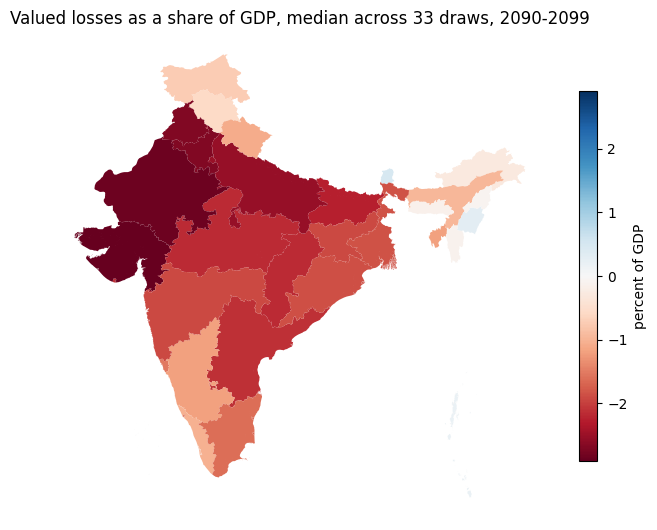

In [ ]:
stats_pct = cilreg.pooled_statistics(
    val.drop(columns=["value", "gdp"]), sample_dims=["batch", "gcm"],
    value_col="pct_gdp", quantiles=[0.05, 0.5, 0.95], weight_col="weight",
)
q50p = stats_pct[stats_pct["statistic"] == "q50"]
mv = states.merge(q50p, on=["ISO", "ID_1"])
lim = float(np.abs(mv["pct_gdp"]).max())
ax = mv.plot(column="pct_gdp", cmap="RdBu",
             norm=TwoSlopeNorm(vmin=-lim, vcenter=0.0, vmax=lim),
             legend=True, figsize=(8, 8),
             legend_kwda={"label": "percent of GDP", "shrink": 0.6})
ax.set_title("Valued losses as a share of GDP, median across 33 draws, 2090-2099")
ax.set_axis_off()